# 13 — Neural Network Layers

A neural network is easier to understand and debug when each operation is treated as a small layer with a forward and backward interface. In this notebook we will implement batched affine and ReLU layers, verify their gradients numerically, and compose them into an affine–ReLU block.

## Learning objectives

- distinguish the neural-layer weight convention from the earlier classifier convention;
- implement batched affine forward and backward passes;
- derive `dX`, `dW`, and `db` using shapes and index notation;
- implement shape-preserving ReLU forward and backward passes;
- use an upstream gradient to check array-valued operations;
- understand why stacked affine layers still represent only one affine function;
- compose layers while keeping their caches separate;
- observe how ReLU activation patterns control gradient flow.


In [1]:
import matplotlib.pyplot as plt
import numpy as np

from cs231n_practice.gradient_check import (
    eval_numerical_gradient_array,
    relative_error,
)

np.set_printoptions(precision=6, suppress=True)
SEED = 42


## 1. Batched affine forward pass

For a batch of $N$ examples, an affine layer computes

$$
S = XW + b.
$$

We will use these shapes:

```text
X: (N, D)    N examples, D input features
W: (D, M)    D input features, M output features
b: (M,)      one bias per output feature
S: (N, M)    one output vector per example
```

NumPy broadcasts $b$ across all $N$ rows.

### A convention change to notice

Our earlier linear-classifier module stores class-major weights with shape
`(C, D)` and computes

```python
scores = X @ W.T + b
```

A general neural-network affine layer conventionally stores weights as
`(D, M)` and computes

```python
out = X @ W + b
```

Both are valid. They differ only in how the weight matrix is stored. Within one implementation, the convention must remain consistent.


### Exercise 1 — Implement batched affine forward

Return the output and a cache containing the values required by the backward pass. Add shape validation for two-dimensional `X` and `W`, one-dimensional `b`, and compatible dimensions.


In [35]:
def affine_forward(
    X: np.ndarray,
    W: np.ndarray,
    b: np.ndarray,
) -> tuple[np.ndarray, tuple[np.ndarray, np.ndarray]]:
    """Return X @ W + b and the values needed for affine backward."""
    if X.ndim != 2:
        raise ValueError("X must be two-dimensional")
    if W.ndim != 2:
        raise ValueError("W must be two-dimensional")
    if b.ndim != 1:
        raise ValueError("b must be one-dimensional")
    if X.shape[1] != W.shape[0]:
        raise ValueError("X and W have incompatible dimensions")
    if W.shape[1] != b.shape[0]:
        raise ValueError("W and b have incompatible dimensions")
    out = X @ W + b
    cache = (X, W)
    return (out, cache)


X = np.array([[1.0, 2.0], [-1.0, 3.0]])
W = np.array([[2.0, -1.0, 0.5], [0.0, 4.0, -2.0]])
b = np.array([0.1, -0.2, 0.3])

scores, affine_cache = affine_forward(X, W, b)

expected_scores = np.array([
    [2.1, 6.8, -3.2],
    [-1.9, 12.8, -6.2],
])
np.testing.assert_allclose(scores, expected_scores)
assert scores.shape == (2, 3)
print(scores)


[[ 2.1  6.8 -3.2]
 [-1.9 12.8 -6.2]]


In [9]:
X @ W + b

array([[ 2.1,  6.8, -3.2],
       [-1.9, 12.8, -6.2]])

## 2. Batched affine backward pass

Assume later layers produce a scalar loss $L$ and send the affine layer

$$
dS = \frac{\partial L}{\partial S},
$$

with shape $(N,M)$. Its element $dS_{nm}$ means $\partial L/\partial S_{nm}$: how sensitive the final loss is to output $m$ of example $n$. We want derivatives with respect to all three affine inputs.

Start by writing one element of the forward pass explicitly:

$$
S_{nm} = \sum_{d=1}^{D} X_{nd}W_{dm}+b_m.
$$

This single equation contains all three derivative formulas. For any input element, ask two questions:

1. Which elements of $S$ depend on it?
2. What is the local derivative of each dependent element?

### Input gradient

Consider one input element $X_{nd}$. It affects every output $S_{nm}$ for the same example $n$, because that input feature participates in all $M$ output calculations. It does not affect outputs belonging to another example. Therefore we add its contributions over $m$:

$$
\frac{\partial L}{\partial X_{nd}}
= \sum_{m=1}^{M}
\frac{\partial L}{\partial S_{nm}}
\frac{\partial S_{nm}}{\partial X_{nd}}.
$$

From the forward equation, $\partial S_{nm}/\partial X_{nd}=W_{dm}$. Substituting $dS_{nm}=\partial L/\partial S_{nm}$ gives

$$
dX_{nd}=\sum_{m=1}^{M}dS_{nm}W_{dm}.
$$

This is exactly element $(n,d)$ of $dS W^T$, because $(W^T)_{md}=W_{dm}$:

$$
dX = dS W^T.
$$

Shape check:

```text
(N, M) @ (M, D) -> (N, D)
```

### Weight gradient

Now consider one weight $W_{dm}$. It connects input feature $d$ to output feature $m$ and is reused for every example $n$. Thus it affects $S_{1m},S_{2m},\ldots,S_{Nm}$, and their contributions must be added:

$$
\frac{\partial L}{\partial W_{dm}}
= \sum_{n=1}^{N}
\frac{\partial L}{\partial S_{nm}}
\frac{\partial S_{nm}}{\partial W_{dm}}.
$$

The local derivative is $\partial S_{nm}/\partial W_{dm}=X_{nd}$, so

$$
\frac{\partial L}{\partial W_{dm}}
=
\sum_{n=1}^{N}
X_{nd}\,dS_{nm}.
$$

In matrix form,

$$
dW = X^T dS.
$$

The sum over examples is performed by matrix multiplication:

```text
(D, N) @ (N, M) -> (D, M)
```

### Bias gradient

Finally, $b_m$ is added to output $m$ for every example:

$$
S_{nm} = \cdots + b_m.
$$

For each of those outputs, the local derivative is

$$
\frac{\partial S_{nm}}{\partial b_m}=1.
$$

Applying the chain rule and adding all $N$ paths gives

$$
db_m = \sum_{n=1}^{N} dS_{nm},
$$

or

```python
db = dS.sum(axis=0)
```

This is gradient accumulation caused by broadcasting. NumPy copied the same conceptual bias across the rows during the forward pass, so backward must sum those row contributions back into one bias vector.

### The three formulas together

$$
dX=dS W^T,
\qquad
dW=X^T dS,
\qquad
db=\sum_{n=1}^{N}dS_{n,:}.
$$

The transposes are not arbitrary rules to memorize: they arrange the indices so matrix multiplication performs exactly the sums derived above.


### Exercise 2 — Implement batched affine backward

Use only the upstream gradient and cached forward values. Check that each returned gradient has the same shape as its corresponding forward input.


In [4]:
def affine_backward(
    dS: np.ndarray,
    cache: tuple[np.ndarray, np.ndarray],
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Return gradients with respect to X, W, and b."""
    X = cache[0]
    W = cache[1]
    dX = dS @ W.T
    dW = X.T @ dS
    db = dS.sum(axis=0)

    return (dX, dW, db)


upstream = np.array([
    [1.0, -2.0, 0.5],
    [-1.0, 3.0, 2.0],
])
dX, dW, db = affine_backward(upstream, affine_cache)

np.testing.assert_allclose(dX, [[4.25, -9.0], [-4.0, 8.0]])
np.testing.assert_allclose(dW, [[2.0, -5.0, -1.5], [-1.0, 5.0, 7.0]])
np.testing.assert_allclose(db, [0.0, 1.0, 2.5])
assert dX.shape == X.shape
assert dW.shape == W.shape
assert db.shape == b.shape

print("dX:\n", dX)
print("dW:\n", dW)
print("db:", db)


dX:
 [[ 4.25 -9.  ]
 [-4.    8.  ]]
dW:
 [[ 2.  -5.  -1.5]
 [-1.   5.   7. ]]
db: [0.  1.  2.5]


## 3. Checking an array-valued layer

The affine layer returns an array $S$, but a gradient is ultimately defined with respect to a scalar loss. Suppose the part of the network after this layer has already told us its upstream gradient $dS$. For a numerical check, we hold this chosen $dS$ constant and deliberately construct the simple scalar

$$
L = \sum_{n,m} S_{nm}\,dS_{nm}.
$$

This is the elementwise inner product $L=\langle S,dS\rangle$. It is a **temporary checking objective**, not a claim that the real training loss is normally this formula. We choose it because its derivative with respect to each output is exactly the upstream value we want to test:

$$
\frac{\partial L}{\partial S_{nm}}=dS_{nm}.
$$

For a particular input coordinate $X_{nd}$, the chain rule then says

$$
\frac{\partial L}{\partial X_{nd}}
=\sum_{i,j}dS_{ij}
\frac{\partial S_{ij}}{\partial X_{nd}}.
$$

The numerical checker approximates every $\partial S_{ij}/\partial X_{nd}$ by perturbing $X_{nd}$, multiplies those output changes by $dS_{ij}$, and sums them. That sum is a vector–Jacobian product: the same quantity that analytical backpropagation computes. `eval_numerical_gradient_array` performs this inner product internally, so we do not need to construct $L$ in the code ourselves.

For example, to check $dX$ while holding $W$ and $b$ fixed:

```python
numerical_dX = eval_numerical_gradient_array(
    lambda candidate_X: affine_forward(candidate_X, W, b)[0],
    X,
    upstream,
)
```

Each parameter is checked independently while all other inputs remain fixed.


### Exercise 3 — Numerically check all affine gradients

Compute numerical gradients for `X`, `W`, and `b`, then report their relative errors. Use `float64` inputs and expect each error to be very small.


In [6]:
X_check = np.array([[0.2, -0.4], [1.1, 0.3]], dtype=np.float64)
W_check = np.array(
    [[0.7, -1.2, 0.5], [-0.3, 0.8, 1.4]],
    dtype=np.float64,
)
b_check = np.array([0.1, -0.2, 0.05], dtype=np.float64)
upstream_check = np.array(
    [[1.0, -0.5, 2.0], [-1.5, 0.25, 0.75]],
    dtype=np.float64,
)

out, cache = affine_forward(X_check, W_check, b_check)
dX, dW, db = affine_backward(upstream_check, cache)

numerical_dX = eval_numerical_gradient_array(
    lambda candidate_X: affine_forward(candidate_X, W_check, b_check)[0],
    X_check,
    upstream_check,
)
numerical_dW = eval_numerical_gradient_array(
    lambda candidate_W: affine_forward(X_check, candidate_W, b_check)[0],
    W_check,
    upstream_check,
)
numerical_db = eval_numerical_gradient_array(
    lambda candidate_b: affine_forward(X_check, W_check, candidate_b)[0],
    b_check,
    upstream_check,
)

errors = {
    "dX": relative_error(dX, numerical_dX),
    "dW": relative_error(dW, numerical_dW),
    "db": relative_error(db, numerical_db),
}
print(errors)
assert all(error < 1e-8 for error in errors.values())


{'dX': 7.26097245002397e-12, 'dW': 9.412708707794522e-12, 'db': 3.2757130341457945e-12}


## 4. ReLU as an elementwise layer

The rectified linear unit applies

$$
H = \max(0,S)
$$

independently to every element. It preserves the input shape.

For $S>0$, the local derivative is $1$. For $S<0$, it is $0$. At exactly zero, we use the common implementation convention of gradient $0$:

$$
dS = dH \odot \mathbb{1}[S>0].
$$

ReLU therefore acts like a gate during backpropagation:

- positive forward values pass the upstream gradient through;
- negative and zero forward values block it.

A vectorized implementation works for arrays of any shape. Copying `dH` before masking is another valid approach, but the caller's upstream array must not be mutated.


### Exercise 4 — Implement and check batched ReLU

Implement shape-preserving forward and backward functions without loops. Verify the backward pass numerically using inputs that stay away from zero.


In [15]:
def relu_forward(X: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    """Apply ReLU elementwise and cache its input."""
    out = np.maximum(0.0, X)
    return (out, X)


def relu_backward(dout: np.ndarray, cache: np.ndarray) -> np.ndarray:
    """Apply the cached ReLU mask to an upstream gradient."""
    local = (cache > 0).astype(np.float32)
    return dout * local


X_relu = np.array([
    [-1.5, 0.4, 2.0],
    [3.0, -0.7, -2.0],
], dtype=np.float64)
upstream_relu = np.array([
    [2.0, -3.0, 0.5],
    [-1.0, 4.0, 2.5],
], dtype=np.float64)
upstream_before = upstream_relu.copy()

out_relu, relu_cache = relu_forward(X_relu)
dX_relu = relu_backward(upstream_relu, relu_cache)
numerical_dX_relu = eval_numerical_gradient_array(
    lambda candidate_X: relu_forward(candidate_X)[0],
    X_relu,
    upstream_relu,
)

np.testing.assert_allclose(out_relu, np.maximum(0.0, X_relu))
np.testing.assert_array_equal(upstream_relu, upstream_before)
assert dX_relu.shape == X_relu.shape
assert relative_error(dX_relu, numerical_dX_relu) < 1e-8
print("ReLU output:\n", out_relu)
print("ReLU gradient:\n", dX_relu)


ReLU output:
 [[0.  0.4 2. ]
 [3.  0.  0. ]]
ReLU gradient:
 [[ 0.  -3.   0.5]
 [-1.   0.   0. ]]


## 5. Why a nonlinear activation is necessary

Suppose two affine layers are stacked without an activation:

$$
H = XW_1+b_1,
$$

$$
S = HW_2+b_2.
$$

Substitute the first equation into the second:

$$
S = (XW_1+b_1)W_2+b_2,
$$

$$
S = X(W_1W_2) + (b_1W_2+b_2).
$$

Define

$$
W_{\text{combined}}=W_1W_2,
\qquad
b_{\text{combined}}=b_1W_2+b_2.
$$

Then

$$
S=XW_{\text{combined}}+b_{\text{combined}},
$$

which is still one affine transformation. Adding more affine layers without nonlinearities does not increase the kinds of functions the network can represent.

Inserting ReLU changes the model to

$$
S = \operatorname{ReLU}(XW_1+b_1)W_2+b_2.
$$

The activation pattern depends on $X$, so there is generally no single fixed affine matrix that replaces the whole network.


### Exercise 5 — Collapse two affine layers

Verify numerically that two consecutive affine layers equal one combined affine layer. Then insert ReLU and explain in a short Markdown cell why the same combined weights no longer reproduce the result in general.


In [25]:
X = np.array([[1.0, -2.0], [0.5, 3.0]])
W1 = np.array([[1.0, -0.5, 2.0], [0.25, 1.5, -1.0]])
b1 = np.array([0.1, -0.2, 0.3])
W2 = np.array([[1.0, -2.0], [0.5, 0.75], [-1.5, 1.0]])
b2 = np.array([0.2, -0.4])

# Compute the two-affine-layer output.
hidden_affine, _ = affine_forward(X, W1, b1)
two_layer_affine, _ = affine_forward(hidden_affine, W2, b2)

# Derive the equivalent single-layer parameters.
combined_W = W1@W2
combined_b = b1@W2+b2
single_layer_affine, _ = affine_forward(X, combined_W, combined_b)

np.testing.assert_allclose(two_layer_affine, single_layer_affine)
print("Two affine layers:\n", two_layer_affine)
print("One combined affine layer:\n", single_layer_affine)

# Insert ReLU between the original affine layers.
hidden_relu, _ = relu_forward(affine_forward(X, W1, b1)[0])
two_layer_relu, _ = affine_forward(hidden_relu, W2, b2)
print("With ReLU:\n", two_layer_relu)


Two affine layers:
 [[-7.5    -0.075 ]
 [ 6.125  -1.7625]]
One combined affine layer:
 [[-7.5    -0.075 ]
 [ 6.125  -1.7625]]
With ReLU:
 [[-5.65    2.7   ]
 [ 3.575  -0.0625]]


In [20]:
(X @ W1 + b1) @ W2 + b2

array([[-7.5   , -0.075 ],
       [ 6.125 , -1.7625]])

Without ReLU, substituting the first affine equation into the second produces one combined affine transformation. ReLU cannot be absorbed into fixed combined weights because its mask depends on the input. Different examples can activate different hidden units, so the network applies different effective linear transformations in different input regions.

## 6. Composing an affine–ReLU block

A small composite layer can call primitive layers in the forward pass:

```text
X ── affine ── S ── ReLU ── H
```

Its cache should retain the separate primitive caches:

```python
cache = (affine_cache, relu_cache)
```

The backward pass follows the graph in reverse:

```text
dX ← affine backward ← dS ← ReLU backward ← dH
```

Composition does not introduce new derivative rules. It organizes already verified operations.


### Exercise 6 — Implement and check affine–ReLU

Implement both composite functions using your primitive layer functions. Numerically verify `dX`, `dW`, and `db`.


In [32]:
def affine_relu_forward(
    X: np.ndarray,
    W: np.ndarray,
    b: np.ndarray,
) -> tuple[np.ndarray, tuple]:
    hidden_affine, affine_cache = affine_forward(X, W, b)
    hidden_relu, relu_cache = relu_forward(hidden_affine)
    cache = (affine_cache, relu_cache)
    return (hidden_relu, cache)



def affine_relu_backward(
    dout: np.ndarray,
    cache: tuple,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    affine_cache, relu_cache = cache

    d_affine = relu_backward(dout, relu_cache)
    dX, dW, db = affine_backward(d_affine, affine_cache)

    return dX, dW, db
    # relu_cache = cache[1]
    # affine_cache = cache[0]
    # relu_local = (relu_cache > 0).astype(np.float32)
    # relu_dout = dout * relu_local
    # X = affine_cache[0]
    # W = affine_cache[1]
    # dX = relu_dout @ W.T
    # dW = X.T @ relu_dout
    # db = relu_dout.sum(axis=0)
    # return (dX, dW, db)


X_block = np.array([[0.5, -1.0], [1.5, 0.25]], dtype=np.float64)
W_block = np.array(
    [[0.8, -0.4, 1.2], [-0.6, 0.9, 0.5]],
    dtype=np.float64,
)
b_block = np.array([0.2, -0.1, 0.3], dtype=np.float64)
upstream_block = np.array(
    [[1.0, -2.0, 0.5], [-0.5, 1.5, 2.0]],
    dtype=np.float64,
)

out_block, block_cache = affine_relu_forward(X_block, W_block, b_block)
dX_block, dW_block, db_block = affine_relu_backward(
    upstream_block,
    block_cache,
)

numerical_dX_block = eval_numerical_gradient_array(
    lambda candidate_X: affine_relu_forward(candidate_X, W_block, b_block)[0],
    X_block,
    upstream_block,
)
numerical_dW_block = eval_numerical_gradient_array(
    lambda candidate_W: affine_relu_forward(X_block, candidate_W, b_block)[0],
    W_block,
    upstream_block,
)
numerical_db_block = eval_numerical_gradient_array(
    lambda candidate_b: affine_relu_forward(X_block, W_block, candidate_b)[0],
    b_block,
    upstream_block,
)

block_errors = {
    "dX": relative_error(dX_block, numerical_dX_block),
    "dW": relative_error(dW_block, numerical_dW_block),
    "db": relative_error(db_block, numerical_db_block),
}
print("output:\n", out_block)
print("errors:", block_errors)
np.testing.assert_allclose(
    dX_block, numerical_dX_block, rtol=1e-8, atol=1e-9
)
np.testing.assert_allclose(
    dW_block, numerical_dW_block, rtol=1e-8, atol=1e-9
)
np.testing.assert_allclose(
    db_block, numerical_db_block, rtol=1e-8, atol=1e-9
)


output:
 [[1.2   0.    0.4  ]
 [1.25  0.    2.225]]
errors: {'dX': 7.430088290714451e-12, 'dW': 0.0018041124150158794, 'db': 6.16129369749773e-12}


## 7. ReLU activation patterns and gradient flow

For a layer with pre-activations $S$, the **active fraction** is the fraction of elements satisfying $S>0$. Only those elements pass gradients backward.

Bias can shift the activation pattern:

- a strongly negative bias can deactivate most units;
- a strongly positive bias can activate most units;
- an intermediate bias often produces a mixture.

A unit that is inactive for every example in a batch contributes zero gradient through ReLU for that batch. This does not automatically mean the unit is permanently dead, but persistent inactivity across data and updates is a warning sign.


### Exercise 7 — Measure activation and gradient flow

For each bias shift, compute affine pre-activations, ReLU outputs, and the gradient produced by an all-ones upstream array. Record:

- fraction of positive pre-activations;
- fraction of nonzero input gradients with respect to the pre-activations.

Plot both fractions against bias. Explain why the two curves should match in this experiment.


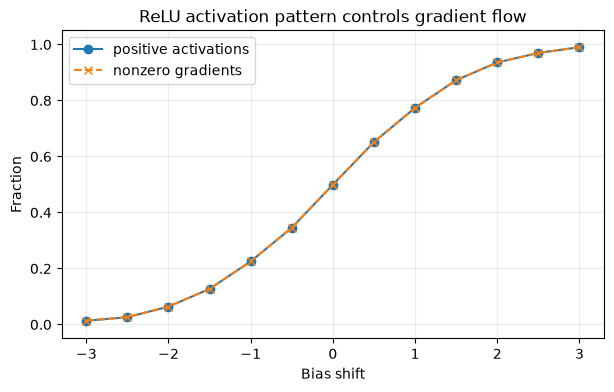

In [33]:
generator = np.random.default_rng(SEED)
X_experiment = generator.normal(size=(200, 20))
W_experiment = generator.normal(scale=0.3, size=(20, 30))
bias_shifts = np.linspace(-3.0, 3.0, 13)

active_fractions = []
gradient_fractions = []

for shift in bias_shifts:
    # Compute pre-activations using a constant bias vector.
    # Give all 30 neurons the same bias for this experiment.
    bias = np.full(W_experiment.shape[1], shift)
    # Raw affine values before ReLU: S = XW + b.
    pre_activations, _ = affine_forward(
        X_experiment,
        W_experiment,
        bias,
    )
    # Values after ReLU: H = max(0, S).
    activations, relu_cache = relu_forward(pre_activations)
    upstream = np.ones_like(activations)
    # Gradient with respect to the values before ReLU.
    pre_activation_gradient = relu_backward(
        upstream,
        relu_cache,
    )

    # Fraction of raw affine values that passed through ReLU.
    active_fractions.append(np.mean(pre_activations > 0))
    # Fraction of locations through which a gradient passed.
    gradient_fractions.append(np.mean(pre_activation_gradient != 0))

np.testing.assert_allclose(active_fractions, gradient_fractions)

plt.figure(figsize=(7, 4))
plt.plot(bias_shifts, active_fractions, "o-", label="positive activations")
plt.plot(
    bias_shifts,
    gradient_fractions,
    "x--",
    label="nonzero gradients",
)
plt.xlabel("Bias shift")
plt.ylabel("Fraction")
plt.title("ReLU activation pattern controls gradient flow")
plt.ylim(-0.05, 1.05)
plt.grid(alpha=0.25)
plt.legend()
plt.show()


## 8. Layer-design checklist

A reliable layer implementation should make these points explicit:

1. What are the input and output shapes?
2. Which values must the forward pass cache?
3. What shape does the upstream gradient have?
4. Which local derivative does each input receive?
5. Where does broadcasting imply summation in the backward pass?
6. Does each returned gradient match its corresponding input shape?
7. Does backward avoid unexpected mutation?
8. Do analytical and numerical gradients agree away from nondifferentiable points?
9. Does the implementation consistently follow one weight-layout convention?

## Reflection

Add a Markdown cell answering:

1. How does the neural-layer weight convention differ from our linear-classifier convention?
2. Why is $dX=dS W^T$?
3. Why is $dW=X^T dS$, and which dimension is summed out?
4. Why does $db$ sum over the batch dimension?
5. What does the upstream gradient mean for an array-valued layer?
6. Why does `eval_numerical_gradient_array` need an upstream gradient?
7. Why is the pre-activation commonly cached for ReLU backward? Under our derivative-at-zero convention, could the output also reconstruct the required mask?
8. What happens to the gradient at negative, positive, and exactly zero ReLU inputs?
9. Why do two affine layers without an activation collapse into one affine layer?
10. What prevents affine–ReLU–affine from collapsing in the same way?
11. Why are primitive caches kept separately in the composite block?
12. What did the bias-shift experiment show about ReLU and gradient flow?
13. What limitations remain in this notebook's layer implementations?

After completing and reviewing this notebook, we will move the verified affine, ReLU, and affine–ReLU functions into `cs231n_practice/layers.py` with focused tests.


1. Linear classifier stores weights as (C, D) and calculates: scores = X @ W.T + b . The general affine layer stores weights as (D, M) and calculates: out = X @ W + b. Both conventions are valid, but transposes and gradient formulas must remain consistent with the chosen convention.
2. One input value $X_{nd}$ affects every output feature $S_{nm}$ for the same example. Applying the chain rule gives: $dX_{nd}=\sum_m dS_{nm}W_{dm}.$
Matrix multiplication with $W^T$ performs exactly this sum: $dX=dS W^T.$
3. One weight $W_{dm}$ is reused for every example in the batch. Its gradient therefore accumulates contributions from all examples:
$
dW_{dm}=\sum_n X_{nd}dS_{nm}.
$ The batch dimension $N$ is summed out by:
$
dW=X^T dS.
$
4. The same bias $b_m$ is added to output $m$ for every example. Therefore, every example contributes to its gradient:
$
db_m=\sum_n dS_{nm}.
$
5. For an array-valued layer:
$
dS_{nm}=\frac{\partial L}{\partial S_{nm}}.
$
Each element says how sensitive the final scalar loss is to one element of the layer output.
6. An array output has a full Jacobian rather than one ordinary gradient. The upstream gradient tells the checker how changes in all output elements should be combined into the derivative of a scalar objective.
Conceptually, it checks:
$
L=\sum_{n,m}S_{nm}dS_{nm}.
$
This is a temporary checking objective whose derivative with respect to $S$ is the chosen dS.
7. The pre-activation directly determines the local derivative:
$
\mathbb{1}[S>0].
$Under our convention that the derivative at zero is also zero, the ReLU output could reconstruct the same mask because: output > 0 is equivalent to: pre_activation > 0. Caching the pre-activation keeps the backward implementation closely connected to the original mathematical operation.
8. Negative input: gradient is blocked and becomes zero.
Positive input: upstream gradient passes through unchanged.
Exactly zero: the derivative does not mathematically exist; our implementation chooses zero.
9. Substitution gives: $(XW_1+b_1)W_2+b_2=X(W_1W_2)+(b_1W_2+b_2).$
The combined weights and bias are: $W_{\text{combined}}=W_1W_2,$ $b_{\text{combined}}=b_1W_2+b_2.$
Therefore, the composition is still affine.
10. ReLU introduces an input-dependent mask. Different inputs can activate different hidden units, so the network applies different effective affine transformations in different input regions. No single fixed weight matrix generally represents all those regions.
11. Each backward operation needs the values saved by its corresponding forward operation:
- ReLU backward needs its activation mask;
- affine backward needs its input and weights.
Keeping separate caches preserves the computation graph and prevents values from different operations from becoming confused.
12. A negative bias moved more pre-activations below zero, causing ReLU to block more activations and gradients. A positive bias activated more units and allowed gradients through more positions.
Because the upstream gradient was all ones, the fraction of nonzero gradients exactly matched the fraction of positive pre-activations.
13. 
- Affine functions currently support only two-dimensional batches.
- Input validation is incomplete.
- Only ReLU is implemented.
- There is no Softmax loss or complete neural-network model yet.
- There is no parameter initialization or training loop.
- Numerical gradient checking is too expensive for large arrays.
- ReLU checks must avoid its nondifferentiable zero point.
- The layer implementations have not yet been moved into reusable modules with focused tests.